## Machine Learning Essentials Exercise 1
### 1 Exploring the Data

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images size: (1797, 8, 8)


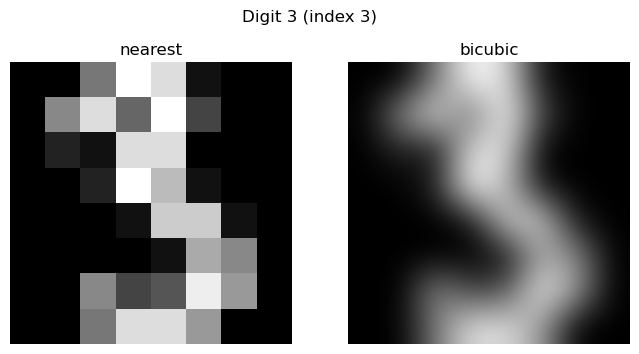

In [2]:
# load the dataset
digits = load_digits()

print(digits.keys())

# eX_trainacts data, images, target, target_names
data = digits['data']
images = digits['images']
target = digits['target']
target_names = digits['target_names']

# size of the images
images_size = images.shape

print(f'Images size: {images_size}')

# visualize one image of a 3
# find an idx where target == 3
digit = 3
idx = np.where(target == digit)[0][0] # returns the first index where target is matched
img = images[idx]

# check if img is a 2-D array
assert 2 == len(img.shape), 'The image is not a 2-D array'

# plot with the two interpolation methods('nearest' and 'bicubic')
plt.figure(figsize=(8, 4))
plt.gray()

plt.subplot(1, 2, 1)
plt.imshow(img, interpolation='nearest')
plt.title('nearest')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img, interpolation='bicubic')
plt.title('bicubic')
plt.axis('off')

plt.suptitle(f'Digit {digit} (index {idx})')
plt.show()

# filter the dataset for '3' and '9'
mask = np.isin(target, [3, 9])

data_39 = data[mask]
target_39 = target[mask]

# split the filtered dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    data_39,
    target_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)


### 2 Hand-crafted classifier

#### 2.1 Feature Construction

In [3]:
# select the images that are 3 and 9
mask3 = np.isin(y_train, 3)
mask9 = np.isin(y_train, 9)

img3s = X_train[mask3]
img9s = X_train[mask9]

# find the average of each pixel across all images
avg_img3s = img3s.mean(axis=0)
avg_img9s = img9s.mean(axis=0)

diff = np.abs(avg_img3s - avg_img9s)

# find the two pixels position (indices) with biggest difference
best_pixels_idx = np.argsort(diff)[::-1]

best_idx1 = best_pixels_idx[0]
best_idx2 = best_pixels_idx[1]

print("Selected pixel indices:", best_idx1, best_idx2)

def features2d(x):
    f1 = x[:, best_idx1]
    f2 = x[:, best_idx2]

    features = np.column_stack([f1, f2])
    
    return features
    
# build features for the training and test sets
training_features = features2d(X_train)
test_features = features2d(X_test)

Selected pixel indices: 26 18


#### 2.2 Scatter plot

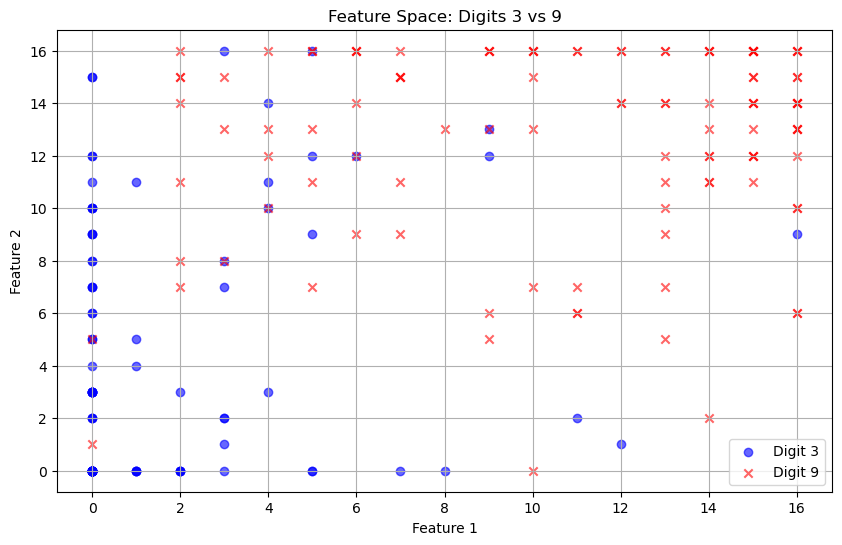

In [4]:
plt.figure(figsize=(10, 6))

# separate features by class
mask3 = np.isin(y_train, 3)
mask9 = np.isin(y_train, 9)

f1_train3 = training_features[mask3, 0]
f2_train3 = training_features[mask3, 1]
f1_train9 = training_features[mask9, 0]
f2_train9 = training_features[mask9, 1]

plt.scatter(f1_train3, f2_train3, label='Digit 3', alpha=0.6, marker='o', color='blue')
plt.scatter(f1_train9, f2_train9, label='Digit 9', alpha=0.6, marker='x', color='red')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Feature Space: Digits 3 vs 9')
plt.legend()
plt.grid()
plt.show()


#### 2.3 Decision rule

In [5]:
def nearest_mean(training_features, training_labels,  test_features):
    # find  the mean for 3 and 9
    mask3 = np.isin(training_labels, -1)
    mask9 = np.isin(training_labels, 1)
    
    mean3 = training_features[mask3].mean(axis=0)
    mean9 = training_features[mask9].mean(axis=0)

    # for each test points, check which mean is closer
    predicted_labels = []

    for point in test_features:
        dist_to_3 = np.linalg.norm(point - mean3)
        dist_to_9 = np.linalg.norm(point - mean9)

        if (dist_to_3 < dist_to_9):
            predicted_labels.append(-1)
        else:
            predicted_labels.append(1)

    return np.array(predicted_labels)

# use -1 for digit 3 and 1 for digit 9 in all later tasks
y_train_changed = np.where(y_train == 3, -1, 1)
y_test_changed = np.where(y_test == 3, -1, 1)

predicted_train_labels = nearest_mean(training_features, y_train_changed, training_features)
predicted_test_labels = nearest_mean(training_features, y_train_changed, test_features)

# compute the errors for both predicted labels
def compute_error(predicted_labels, true_labels):
    wrong = np.sum(true_labels != predicted_labels)
    total = len(true_labels)
    return wrong / total

training_error = compute_error(predicted_train_labels, y_train_changed)
test_error = compute_error(predicted_test_labels, y_test_changed)

print('Training error:', training_error)
print('Test error:', test_error)


Training error: 0.0967741935483871
Test error: 0.10273972602739725


In [6]:
# the errors are not so bad but still we want to optimize our model by manual tuning
def custom_classifier(test_features, beta, b):
    result = test_features @ beta + b
    return np.where(result >= 0, 1, -1)

mask3 = np.isin(y_train_changed, -1)
mask9 = np.isin(y_train_changed, 1)

mean3 = training_features[mask3].mean(axis=0)
mean9 = training_features[mask9].mean(axis=0)

beta = mean9 - mean3

candidate_bs = np.linspace(-200, 50, 500)

best_b = None
best_error = 1.0

for b_candidate in candidate_bs:
    predicted_test_labels = custom_classifier(test_features, beta, b_candidate)
    error = compute_error(predicted_test_labels, y_test_changed)

    if error < best_error:
        best_error = error
        best_b = b_candidate

print("Best b:", best_b)
print("Best test error:", best_error)

predicted_train_custom = custom_classifier(training_features, beta, best_b)
predicted_test_custom = custom_classifier(test_features, beta, best_b)

training_error_custom = compute_error(predicted_train_custom, y_train_changed)
test_error_custom = compute_error(predicted_test_custom, y_test_changed)

print("Training error with custom classifier:", training_error_custom)
print("Test error with custom classifier:", test_error_custom)

Best b: -123.84769539078157
Best test error: 0.0958904109589041
Training error with custom classifier: 0.0967741935483871
Test error with custom classifier: 0.0958904109589041


#### 2.4 Visualize the decision regions

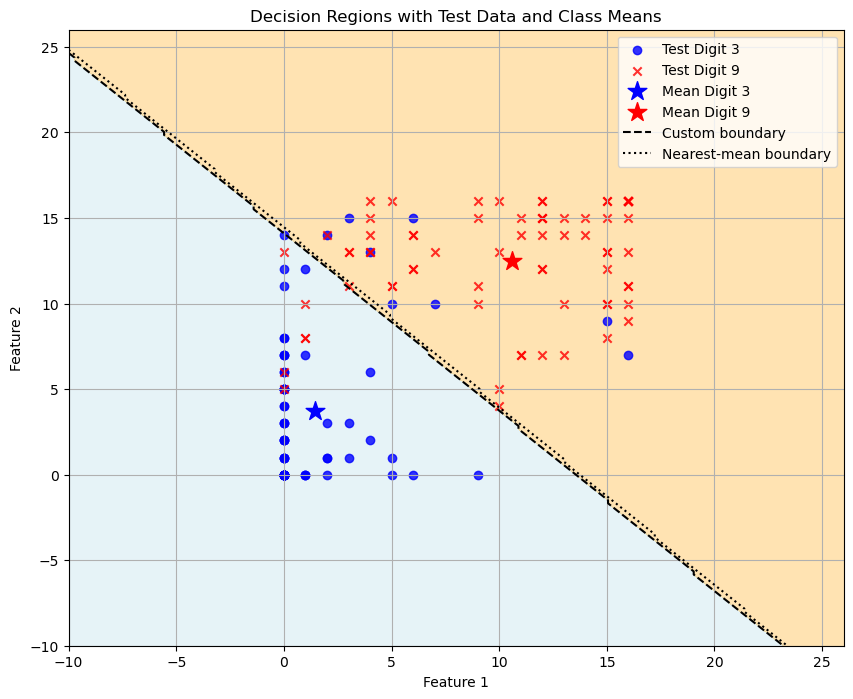

In [7]:
grid_size = 200

# eX_trainact each feature column
f1 = training_features[:, 0]
f2 = training_features[:, 1]

# find min and max for each feature separately
min_f1_raw = f1.min()
max_f1_raw = f1.max()
min_f2_raw = f2.min()
max_f2_raw = f2.max()

# add padding
min_f1 = min_f1_raw - 10
max_f1 = max_f1_raw + 10
min_f2 = min_f2_raw - 10
max_f2 = max_f2_raw + 10

# create the grid with the grid_size 200
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# stack F1 and F2 into two columns but they should be flatten (output will have a shape of (40,000, 2))
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

# predict using both classifiers for the grid
predict_custom_classifier = custom_classifier(grid_features, beta, best_b).reshape(F1.shape)
predict_nearest_mean = nearest_mean(training_features, y_train_changed, grid_features).reshape(F1.shape)

# plot the decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, predict_custom_classifier, levels=[-1, 0, 1], colors=['lightblue', 'orange'], alpha=0.3)

# plot decision boundary lines for both classifiers
plt.contour(F1, F2, predict_custom_classifier, levels=[0], colors='black', linestyles='--')
plt.contour(F1, F2, predict_nearest_mean, levels=[0], colors='black', linestyles=':')

# overlay test data on the grid regions
mask3_test = np.isin(y_test_changed, -1)
mask9_test = np.isin(y_test_changed, 1)

f1_test3 = test_features[mask3_test, 0]
f2_test3 = test_features[mask3_test, 1]
f1_test9 = test_features[mask9_test, 0]
f2_test9 = test_features[mask9_test, 1]

plt.scatter(f1_test3, f2_test3, label='Test Digit 3', marker='o', color='blue', alpha=0.8)
plt.scatter(f1_test9, f2_test9, label='Test Digit 9', marker='x', color='red', alpha=0.8)

# plot class means
mask3 = np.isin(y_train_changed, -1)
mask9 = np.isin(y_train_changed, 1)

mean3 = training_features[mask3].mean(axis=0)
mean9 = training_features[mask9].mean(axis=0)

plt.scatter(mean3[0], mean3[1], label='Mean Digit 3', marker='*', s=200, color='blue')
plt.scatter(mean9[0], mean9[1], label='Mean Digit 9', marker='*', s=200, color='red')

# for our decision boundaries exist in the legend
plt.plot([], [], color='black', linestyle='--', label='Custom boundary')
plt.plot([], [], color='black', linestyle=':', label='Nearest-mean boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions with Test Data and Class Means')
plt.legend()
plt.grid()
plt.show()


### 3 LDA
#### 3.1 Implement LDA training

In [8]:
def fit_lda(X, y):
    # use the formula/algorithm that fits the cluster means and covmat matrix
    mask_minus1 = np.isin(y, -1)
    mask_plus1 = np.isin(y, 1)

    X_minus1 = X[mask_minus1]
    X_plus1 = X[mask_plus1]

    n_minus1 = X_minus1.shape[0]
    n_plus1 = X_plus1.shape[0]
    N = n_minus1 + n_plus1

    mu_minus1 = X_minus1.mean(axis=0)
    mu_plus1 = X_plus1.mean(axis=0)
    mu = np.vstack([mu_minus1, mu_plus1])

    # find the shared covmat matrix
    centered_minus1 = X_minus1 - mu_minus1
    centered_plus1 = X_plus1 - mu_plus1
    covmat = (centered_minus1.T @ centered_minus1 + centered_plus1.T @ centered_plus1) / N

    # find the class priors
    prior_minus1 = n_minus1 / N
    prior_plus1 = n_plus1 / N
    p = np.array([prior_minus1, prior_plus1])

    return mu, covmat, p

# 2d features from task 2
X2_train = training_features
X2_test = test_features

# full 64-d features with dead pixels removed
pixel_variance = np.var(data_39, axis=0)
active_pixel_mask = pixel_variance >= 0.001
Xfull_train = X_train[:, active_pixel_mask]
Xfull_test = X_test[:, active_pixel_mask]

mu, covmat, p = fit_lda(X2_train, y_train_changed)
mu_full, covmat_full, p_full = fit_lda(Xfull_train, y_train_changed)

#### 3.2 Implement LDA prediction

In [9]:
def predict_lda(mu, covmat, p, X_input):
    # use the decision rule formula to predict beta and bias
    mu_minus1 = mu[0]
    mu_plus1 = mu[1]

    eps = 1e-6
    covmat_stable = covmat + eps * np.eye(covmat.shape[0])
    covmat_inv = np.linalg.inv(covmat_stable)
    beta = covmat_inv @ (mu_plus1 - mu_minus1)
    bias = -0.5 * ((mu_plus1 + mu_minus1) @ beta) + np.log(p[1] / p[0])

    result = X_input @ beta + bias
    
    predicted_labels = []
    for item in result:
        if item >= 0:
            predicted_labels.append(1)
        else:
            predicted_labels.append(-1)
    return np.array(predicted_labels)


predicted_labels_lda_train = predict_lda(mu, covmat, p, X2_train)
predicted_labels_lda_test = predict_lda(mu, covmat, p, X2_test)
training_error_lda = compute_error(predicted_labels_lda_train, y_train_changed)
test_error_lda = compute_error(predicted_labels_lda_test, y_test_changed)

predicted_labels_full_train = predict_lda(mu_full, covmat_full, p_full, Xfull_train)
predicted_labels_full_test = predict_lda(mu_full, covmat_full, p_full, Xfull_test)
training_error_full_lda = np.mean(predicted_labels_full_train != y_train_changed)
test_error_full_lda = np.mean(predicted_labels_full_test != y_test_changed)

print("2D LDA training error:", training_error_lda)
print("2D LDA test error:", test_error_lda)

print("Full LDA training error:", training_error_full_lda)
print("Full LDA test error:", test_error_full_lda)

2D LDA training error: 0.09216589861751152
2D LDA test error: 0.10273972602739725
Full LDA training error: 0.0
Full LDA test error: 0.02054794520547945


#### 3.3 Visualization

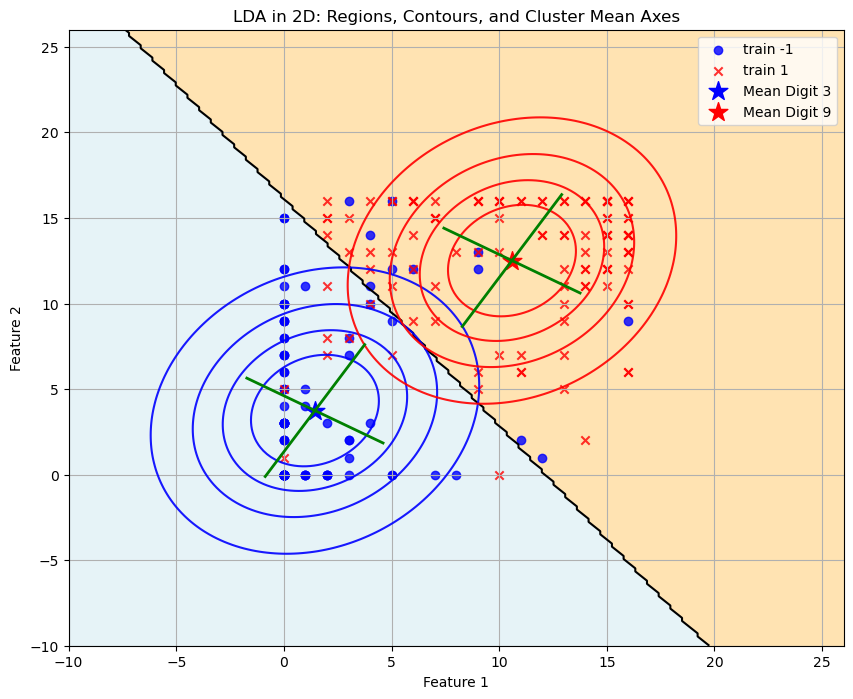

train error: 0.09216589861751152
test error : 0.10273972602739725
train quality: the separation is good on training data
test quality: on test data, the overall prediction looks reasonable


In [10]:
f1 = X2_train[:, 0]
f2 = X2_train[:, 1]

# find min and max for each feature separately
min_f1_raw = f1.min()
max_f1_raw = f1.max()
min_f2_raw = f2.min()
max_f2_raw = f2.max()

# add padding
min_f1 = min_f1_raw - 10
max_f1 = max_f1_raw + 10
min_f2 = min_f2_raw - 10
max_f2 = max_f2_raw + 10

# create the grid with the grid_size 200 which we already declared in task 2.4
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# stack F1 and F2 into two columns but they should be flatten (output will have a shape of (40,000, 2))
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

predicted_grid_labels = predict_lda(mu, covmat, p, grid_features).reshape(F1.shape)

# find the gaussian density so that we can plot an ellipse which visualizes the cluster shape
def gaussian_density(grid_points, mu_value, covmat_matrix):
    covmat_inv = np.linalg.inv(covmat_matrix)
    covmat_det = np.linalg.det(covmat_matrix)
    centered_points = grid_points - mu_value
    quadratic_form = np.einsum('ij,jk,ik->i', centered_points, covmat_inv, centered_points)
    normalization = 1.0 / (2 * np.pi * np.sqrt(covmat_det))
    return normalization * np.exp(-0.5 * quadratic_form)

density_minus1 = gaussian_density(grid_features, mu[0], covmat).reshape(F1.shape)
density_plus1  = gaussian_density(grid_features, mu[1], covmat).reshape(F1.shape)

# find the eigenvalues and eigenvectors which indicate the cluster radiuses along each axis
eigenvalues, eigenvectors = np.linalg.eig(covmat)
cluster_mean_axis_lengths = np.sqrt(np.maximum(eigenvalues, 0))

# plot the decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, predicted_grid_labels, levels=[-1, 0, 1], colors=['lightblue', 'orange'], alpha=0.3)
plt.contour(F1, F2, predicted_grid_labels, levels=[0], colors='black')

# overlay the train data on the 200x200 grid
mask3 = np.isin(y_train_changed, -1)
mask9 = np.isin(y_train_changed,  1)
plt.scatter(X2_train[mask3, 0], X2_train[mask3, 1], label='train -1', marker='o', color='blue', alpha=0.8)
plt.scatter(X2_train[mask9, 0], X2_train[mask9, 1], label='train 1',  marker='x', color='red',  alpha=0.8)

# plot the class means
mean3 = X2_train[mask3].mean(axis=0)
mean9 = X2_train[mask9].mean(axis=0)
plt.scatter(mean3[0], mean3[1], label='Mean Digit 3', marker='*', s=200, color='blue')
plt.scatter(mean9[0], mean9[1], label='Mean Digit 9', marker='*', s=200, color='red')

# plot the gaussian density contours
levels_minus1 = np.linspace(density_minus1.max() * 0.15, density_minus1.max() * 0.75, 4)
levels_plus1  = np.linspace(density_plus1.max()  * 0.15, density_plus1.max()  * 0.75, 4)
plt.contour(F1, F2, density_minus1, levels=levels_minus1, colors='blue', alpha=0.9)
plt.contour(F1, F2, density_plus1,  levels=levels_plus1,  colors='red',  alpha=0.9)

# find and plot the axes that centered at the cluster mean 
for mu_value in [mu[0], mu[1]]:
    for k in range(2):
        principal_vector = eigenvectors[:, k].real
        axis_length = cluster_mean_axis_lengths[k].real
        axis_start = mu_value - axis_length * principal_vector
        axis_end   = mu_value + axis_length * principal_vector
        plt.plot([axis_start[0], axis_end[0]], [axis_start[1], axis_end[1]], color='green', linewidth=2)

plt.title('LDA in 2D: Regions, Contours, and Cluster Mean Axes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

print('train error:', training_error_lda)
print('test error :', test_error_lda)
if training_error_lda < 0.15:
    print('train quality: the separation is good on training data')
else:
    print('train quality: too much overlap is still visible on training data')

if test_error_lda < 0.20:
    print('test quality: on test data, the overall prediction looks reasonable')
else:
    print('test quality: generalization is weak, there is noticeable overlap')

#### 3.4 Quantitative performance evaluation

In [11]:
# perform a 10 fold cross validation on all available data on digits 3 and 9 only
# compare the results with the results from the official LDA implementation in the sklearn package
X_all = data_39[:, active_pixel_mask]
y_all = np.where(target_39 == 3, -1, 1)

folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

custom_cv_errors  = []
sklearn_cv_errors = []

for train_idx, test_idx in folds.split(X_all, y_all):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    mu_cv, cov_cv, p_cv = fit_lda(X_train, y_train)
    predict_cv = predict_lda(mu_cv, cov_cv, p_cv, X_test)
    custom_cv_errors.append(compute_error(predict_cv, y_test))

    sklearn_lda = LinearDiscriminantAnalysis(solver='svd')
    sklearn_lda.fit(X_train, y_train)
    predict_sklearn = sklearn_lda.predict(X_test)
    sklearn_cv_errors.append(compute_error(predict_sklearn, y_test))

custom_cv_errors  = np.array(custom_cv_errors)
sklearn_cv_errors = np.array(sklearn_cv_errors)

print("LDA mean error:", custom_cv_errors.mean())
print("LDA standard deviation: ", custom_cv_errors.std())
print("Sklearn mean error:", sklearn_cv_errors.mean())
print("Sklearn standard deviation: ", sklearn_cv_errors.std())
print("we can say based on the error, our model predicts for labels reasonably well")

LDA mean error: 0.01096096096096096
LDA standard deviation:  0.013426479823488383
Sklearn mean error: 0.01096096096096096
Sklearn standard deviation:  0.013426479823488383
we can say based on the error, our model predicts for labels reasonably well


### 4 SVM

#### 4.1 Implement SVM training

In [12]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    data_39,
    target_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)

# convert labels: digit 3 -> -1, digit 9 -> 1
y_train_svm = np.where(y_train == 3, -1, 1)
y_test_svm = np.where(y_test == 3, -1, 1)

# 2D handcrafted features
X_train_svm_2d = features2d(X_train)
X_test_svm_2d = features2d(X_test)

# full active-pixel features
X_train_svm_full = X_train[:, active_pixel_mask]
X_test_svm_full = X_test[:, active_pixel_mask]

# standardization
scaler_2d = StandardScaler()
X_train_svm_2d_scaled = scaler_2d.fit_transform(X_train_svm_2d)
X_test_svm_2d_scaled = scaler_2d.transform(X_test_svm_2d)

scaler_full = StandardScaler()
X_train_svm_full_scaled = scaler_full.fit_transform(X_train_svm_full)
X_test_svm_full_scaled = scaler_full.transform(X_test_svm_full)

In [13]:
def svm_loss(beta, b, X, y, lam):
    N = X.shape[0]
    margins = y * (X @ beta + b)
    hinge_losses = np.maximum(0, 1 - margins)

    loss = 0.5 * (beta @ beta) + (lam / N) * np.sum(hinge_losses)
    return loss

def svm_gradient(beta, b, X, y, lam):
    N = X.shape[0]
    margins = y * (X @ beta + b)

    active = margins < 1 # only points with margin < 1 contribute to the hinge loss gradient

    grad_beta = beta + (lam / N) * np.sum((-y[active, None]) * X[active], axis=0)
    grad_b = (lam / N) * np.sum(-y[active])

    return grad_beta, grad_b

def fit_svm(X, y, lam=1.0, tau=0.01, T=5000, random_state=0):
    np.random.seed(random_state)

    N, D = X.shape

    # initial guess
    beta = np.random.normal(0, 1, size=D)
    b = 0.0

    losses = []
    train_errors = []
    iterations = []

    best_error = 1.0
    stagnation_counter = 0

    for t in range(T):
        grad_beta, grad_b = svm_gradient(beta, b, X, y, lam)

        beta = beta - tau * grad_beta
        b = b - tau * grad_b

        if t % 10 == 0:
            loss = svm_loss(beta, b, X, y, lam)

            scores = X @ beta + b
            pred_train = np.where(scores >= 0, 1, -1)
            train_error = compute_error(pred_train, y)

            losses.append(loss)
            train_errors.append(train_error)
            iterations.append(t)

            # learning rate schedule
            if train_error < best_error:
                best_error = train_error
                stagnation_counter = 0
            else:
                stagnation_counter += 1

            if stagnation_counter >= 100:
                tau = tau / 10
                stagnation_counter = 0

    history = {
        "iterations": np.array(iterations),
        "losses": np.array(losses),
        "train_errors": np.array(train_errors)
    }

    return beta, b, history

In [14]:
beta_svm_2d, b_svm_2d, history_svm_2d = fit_svm(
    X_train_svm_2d_scaled,
    y_train_svm,
    lam=10.0,
    tau=0.01,
    T=5000,
    random_state=0
)

#### 4.2 Implement SVM prediction

In [15]:
def predict_svm(beta, b, X):
    scores = X @ beta + b
    return np.where(scores >= 0, 1, -1)

In [16]:
pred_train_svm_2d = predict_svm(beta_svm_2d, b_svm_2d, X_train_svm_2d_scaled)
pred_test_svm_2d = predict_svm(beta_svm_2d, b_svm_2d, X_test_svm_2d_scaled)

training_error_svm_2d = compute_error(pred_train_svm_2d, y_train_svm)
test_error_svm_2d = compute_error(pred_test_svm_2d, y_test_svm)

print("SVM 2D training error:", training_error_svm_2d)
print("SVM 2D test error:", test_error_svm_2d)

SVM 2D training error: 0.0967741935483871
SVM 2D test error: 0.10273972602739725


#### 4.3 Visualization

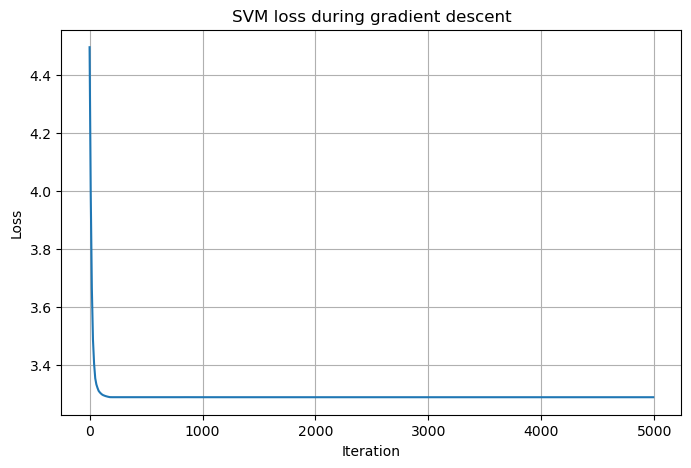

In [17]:
# loss and training error during gradient descent
plt.figure(figsize=(8, 5))
plt.plot(history_svm_2d["iterations"], history_svm_2d["losses"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SVM loss during gradient descent")
plt.grid(True)
plt.show()

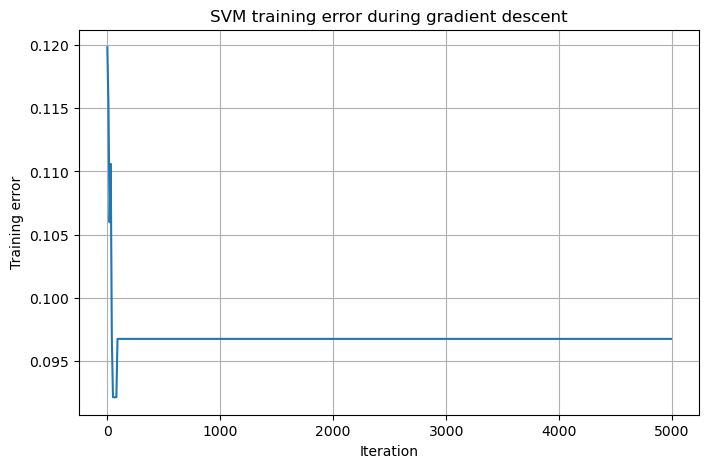

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_svm_2d["iterations"], history_svm_2d["train_errors"])
plt.xlabel("Iteration")
plt.ylabel("Training error")
plt.title("SVM training error during gradient descent")
plt.grid(True)
plt.show()

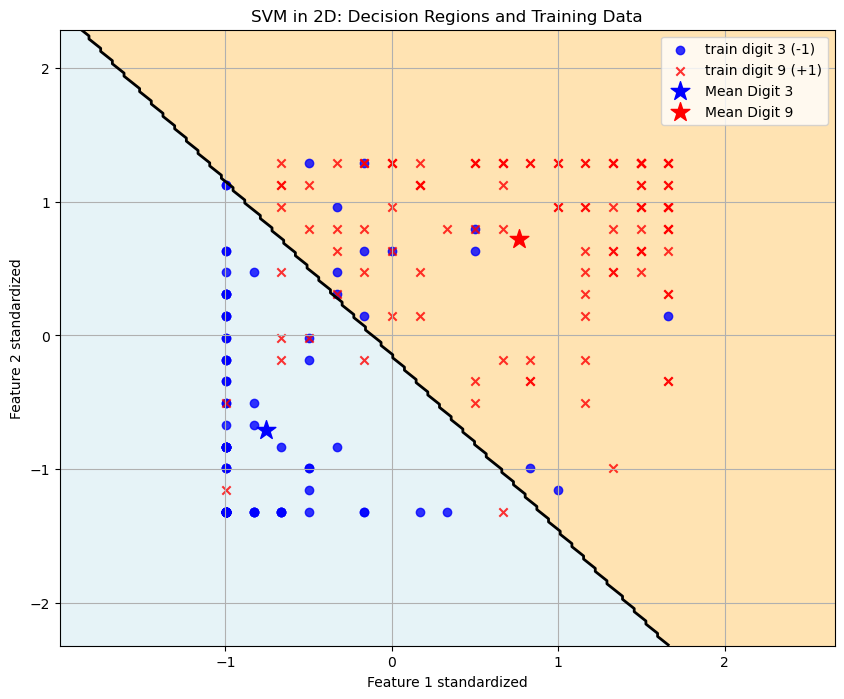

In [19]:
f1 = X_train_svm_2d_scaled[:, 0]
f2 = X_train_svm_2d_scaled[:, 1]

# find min and max for each feature separately
min_f1_raw = f1.min()
max_f1_raw = f1.max()
min_f2_raw = f2.min()
max_f2_raw = f2.max()

# add padding
min_f1 = min_f1_raw - 1
max_f1 = max_f1_raw + 1
min_f2 = min_f2_raw - 1
max_f2 = max_f2_raw + 1

# create the grid with the grid_size 200 which we already declared in task 2.4
grid_size = 200
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# stack F1 and F2 into two columns but they should be flatten (output will have a shape of (40,000, 2))
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

predicted_grid_labels = predict_svm(beta_svm_2d, b_svm_2d, grid_features).reshape(F1.shape)

# plot the decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, predicted_grid_labels, levels=[-1, 0, 1], colors=['lightblue', 'orange'], alpha=0.3)
plt.contour(F1, F2, predicted_grid_labels, levels=[0], colors='black', linewidths=2)

# overlay the train data on the 200x200 grid
mask3 = (y_train_svm == -1)
mask9 = (y_train_svm == 1)

plt.scatter(X_train_svm_2d_scaled[mask3, 0], X_train_svm_2d_scaled[mask3, 1], label='train digit 3 (-1)', marker='o', color='blue', alpha=0.8)
plt.scatter(X_train_svm_2d_scaled[mask9, 0], X_train_svm_2d_scaled[mask9, 1], label='train digit 9 (+1)',  marker='x', color='red',  alpha=0.8)

# plot the class means
mean3 = X_train_svm_2d_scaled[mask3].mean(axis=0)
mean9 = X_train_svm_2d_scaled[mask9].mean(axis=0)

plt.scatter(mean3[0], mean3[1], label='Mean Digit 3', marker='*', s=200, color='blue')
plt.scatter(mean9[0], mean9[1], label='Mean Digit 9', marker='*', s=200, color='red')

plt.title('SVM in 2D: Decision Regions and Training Data')
plt.xlabel('Feature 1 standardized')
plt.ylabel('Feature 2 standardized')
plt.legend()
plt.grid()
plt.show()

#### 4.4 Quantitative performance evaluation

In [20]:
candidate_lambdas = [0.01, 0.1, 1.0, 10.0, 100.0]

folds_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

lambda_errors = []

for lam in candidate_lambdas:
    fold_errors = []

    for train_idx, val_idx in folds_svm.split(X_train_svm_full_scaled, y_train_svm):
        X_cv_train = X_train_svm_full_scaled[train_idx]
        X_cv_val = X_train_svm_full_scaled[val_idx]
        y_cv_train = y_train_svm[train_idx]
        y_cv_val = y_train_svm[val_idx]
        
        beta_cv, b_cv, _ = fit_svm(
            X_cv_train,
            y_cv_train,
            lam=lam,
            tau=0.01,
            T=3000,
            random_state=0
        )

        pred_cv = predict_svm(beta_cv, b_cv, X_cv_val)
        fold_error = compute_error(pred_cv, y_cv_val)
        fold_errors.append(fold_error)

    mean_error = np.mean(fold_errors)
    lambda_errors.append(mean_error)

    print("lambda:", lam, "mean CV error:", mean_error)

best_lambda = candidate_lambdas[np.argmin(lambda_errors)]
print("Best lambda:", best_lambda)

lambda: 0.01 mean CV error: 0.04133192389006342
lambda: 0.1 mean CV error: 0.04133192389006342
lambda: 1.0 mean CV error: 0.009302325581395349
lambda: 10.0 mean CV error: 0.004651162790697674
lambda: 100.0 mean CV error: 0.013742071881606765
Best lambda: 10.0


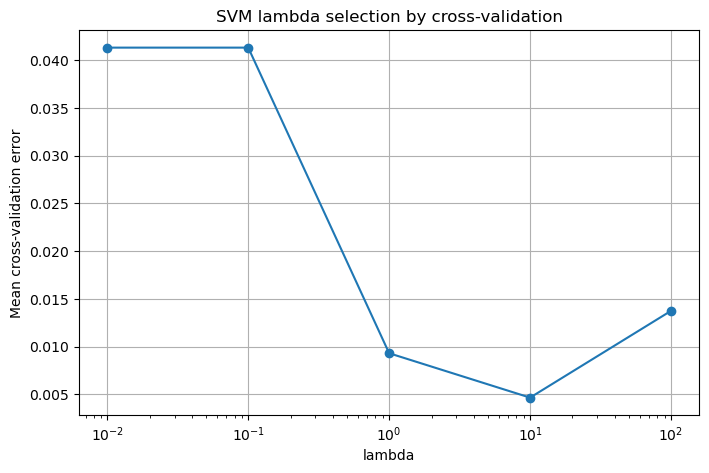

In [21]:
plt.figure(figsize=(8, 5))
plt.semilogx(candidate_lambdas, lambda_errors, marker="o")
plt.xlabel("lambda")
plt.ylabel("Mean cross-validation error")
plt.title("SVM lambda selection by cross-validation")
plt.grid(True)
plt.show()

In [22]:
# train final SVM on full active-pixel features
beta_svm_full, b_svm_full, history_svm_full = fit_svm(
    X_train_svm_full_scaled,
    y_train_svm,
    lam=best_lambda,
    tau=0.01,
    T=5000,
    random_state=0
)

pred_train_svm_full = predict_svm(beta_svm_full, b_svm_full, X_train_svm_full_scaled)
pred_test_svm_full = predict_svm(beta_svm_full, b_svm_full, X_test_svm_full_scaled)

training_error_svm_full = compute_error(pred_train_svm_full, y_train_svm)
test_error_svm_full = compute_error(pred_test_svm_full, y_test_svm)

print("SVM full training error:", training_error_svm_full)
print("SVM full test error:", test_error_svm_full)

SVM full training error: 0.0
SVM full test error: 0.00684931506849315


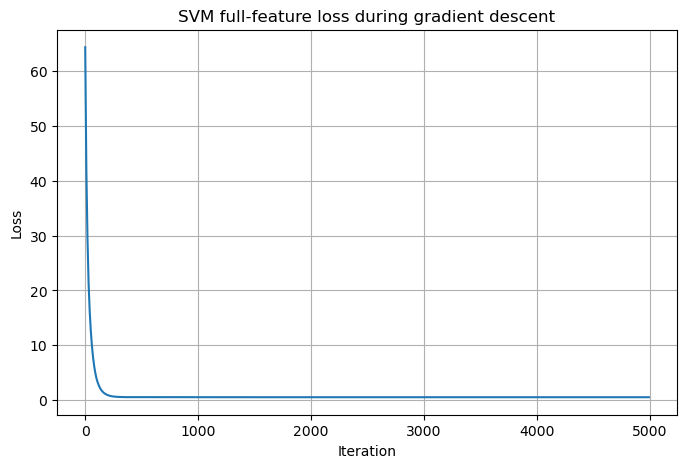

In [23]:
# plot full-feature SVM training curve
plt.figure(figsize=(8, 5))
plt.plot(history_svm_full["iterations"], history_svm_full["losses"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SVM full-feature loss during gradient descent")
plt.grid(True)
plt.show()

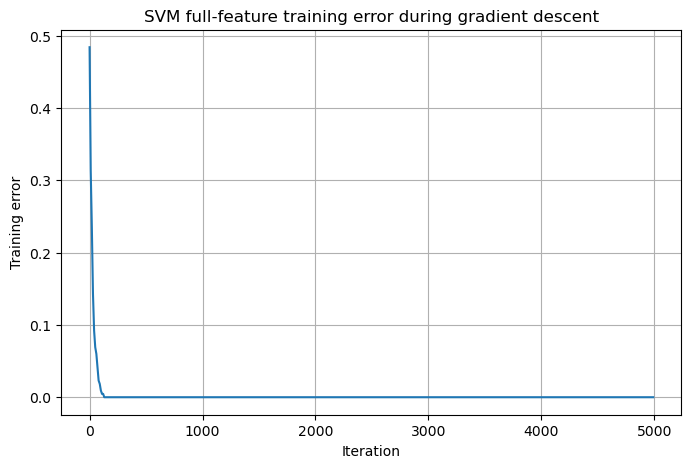

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history_svm_full["iterations"], history_svm_full["train_errors"])
plt.xlabel("Iteration")
plt.ylabel("Training error")
plt.title("SVM full-feature training error during gradient descent")
plt.grid(True)
plt.show()

In [25]:
sklearn_svm = LinearSVC(
    C=best_lambda,
    max_iter=10000,
    random_state=0
)

sklearn_svm.fit(X_train_svm_full_scaled, y_train_svm)

pred_train_sklearn_svm = sklearn_svm.predict(X_train_svm_full_scaled)
pred_test_sklearn_svm = sklearn_svm.predict(X_test_svm_full_scaled)

training_error_sklearn_svm = compute_error(pred_train_sklearn_svm, y_train_svm)
test_error_sklearn_svm = compute_error(pred_test_sklearn_svm, y_test_svm)

print("sklearn LinearSVC training error:", training_error_sklearn_svm)
print("sklearn LinearSVC test error:", test_error_sklearn_svm)

sklearn LinearSVC training error: 0.0
sklearn LinearSVC test error: 0.0136986301369863


In [26]:
print("==================== Final comparison ====================")
print("Nearest mean 2D test error:", test_error)
print("Custom linear classifier 2D test error:", test_error_custom)
print("LDA 2D test error:", test_error_lda)
print("LDA full test error:", test_error_full_lda)
print("SVM 2D test error:", test_error_svm_2d)
print("SVM full test error:", test_error_svm_full)
print("sklearn LinearSVC full test error:", test_error_sklearn_svm)

==================== Final comparison ====================
Nearest mean 2D test error: 0.10273972602739725
Custom linear classifier 2D test error: 0.0958904109589041
LDA 2D test error: 0.10273972602739725
LDA full test error: 0.02054794520547945
SVM 2D test error: 0.10273972602739725
SVM full test error: 0.00684931506849315
sklearn LinearSVC full test error: 0.0136986301369863


Compared with the nearest mean classifier, the SVM achieves better prediction quality when the full active-pixel feature space is used. The nearest mean classifier only uses the handcrafted two-dimentional features and therefore loses much of the original image information. Therefore, its test error is higher.

Compared with LDA, the full-feature SVM achieves a slightly lower test error n this experiment. LDA already performs well because it uses the full active-pixel representation and the covariance structure of the data. However, SVM directly optimizes a margtin-based classification objective, which gives the best test error among the tested classifiers in thi srun.

Overall, the prediction quality improves in the order: nearest mean classifier < full-feature LDA < full-feature SVM.